## **Nivell 1**
1. Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original. Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat. Mostra les primeres 10 files. Addicionalment, fes un print on comprovi que el DNI només té valors únics.

In [705]:
import pandas as pd

In [706]:
def cargar_data(path):
    try:
        df = (
            pd.read_excel(path, header=3, index_col=0)#hay notas en la parte superior
            .sort_values(by=["País d'origen", "Ciutat"])
        )
        df.columns = df.columns.str.strip() 
    except FileNotFoundError:
        raise FileNotFoundError(f"No se encontró el archivo: {path}") #mejor raise que print()
    return df

Notas personales: en este caso es mejor raise que pint para que el programa no continue. pint() es para informar pero sigue ejecutando

In [707]:
df=cargar_data("Data/sprint10.xlsx")

In [708]:
df.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [709]:
print(df['DNI'].is_unique)

True


2. Crea una columna que sigui el nom complet.
Crea una columna si la persona és nascuda a Espanya o no.
Posa el DNI com a índex del DataFrame (noms de files).
Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.
Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).
Mostra tots els canvis que has realitzat en una sola taula.

In [710]:
df['Nom Complet']=df['Nom'] + ' ' + df['Cognoms']
col = df.pop('Nom Complet')
df.insert(0, 'Nom Complet', col)

In [711]:
df['Nascut a Espanya']=df["País d'origen"]=='Espanya'

In [712]:
df=df.set_index('DNI') #para cambiar el indice despues de haber leído el archivo

In [713]:
df.rename(columns={'Dia de Naixement': 'Dia', 'Mes de Naixement': 'Mes', 'Any de Naixement': 'Any'}, inplace=True)

In [714]:
df['Gènere']=df['Gènere'].replace({'H':'Home', 'D': 'Dona', 'A':'Altres'}).fillna('NC')
df

,Nom Complet,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nascut a Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False
37399141L,Laura Schneider Fischer,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False
37368317L,Lea Schneider Schneider,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,False
21390098Z,Mia Fischer,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,False
44060014R,Jonas Schneider,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,False
57441590Y,George Brown Jones,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,False
58204038A,Olivia Brown Brown,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,False


Nota personal: añadir inplace=True resulta como sobreescribir el df con df=df...

3. Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

In [715]:
def combinar_fills(fila):
    if fila['Fills'] == 1:
        return 'Sí'
    elif fila['No Fills'] == 1:
        return 'No'

df['Fills'] = df.apply(combinar_fills, axis=1)

df

,Nom Complet,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nascut a Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,No,1.0,Grup A,False
37399141L,Laura Schneider Fischer,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Sí,NaN,Grup B,False
37368317L,Lea Schneider Schneider,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,1.0,Grup B,False
21390098Z,Mia Fischer,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Sí,NaN,Grup B,False
44060014R,Jonas Schneider,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Sí,NaN,Grup D,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,No,1.0,Grup B,False
57441590Y,George Brown Jones,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Sí,NaN,Grup A,False
58204038A,Olivia Brown Brown,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,No,1.0,Grup A,False


In [716]:
#Opcional
df.drop(columns=['No Fills'], inplace=True)

Nota personal:

**apply:** axis=1 → fila, axis=0 → columna;

*recibe fila/columna → axis indica qué es lo que quieres iterar*

**drop / sum / mean / etc:** axis=1 → columnas, axis=0 → filas;

*axis indica qué dimension eliminar o agregar*

4. Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
Ordena la taula en funció del sou mig.

In [717]:
print(df['Salari mensual'].dtype) #objeto que debemos convertir a numerico y para remplazar simbolos debemos convertir a str

object


Debemos limpiar el formato de Salari mensual: 28.000€ --> 28000

In [718]:
def limpiar_salario(df): #opcional: lo hacemos con una función
    df['Salari mensual'] = (
        df['Salari mensual']
        .str.replace('€','')
        .str.replace('.','', regex=False) #regex busca coincidencias literales y desactiva las expresiones regulares
    )
    df['Salari mensual'] = pd.to_numeric(df['Salari mensual'])
    return df

In [719]:
df = limpiar_salario(df)

In [720]:
taula_resum=df.groupby('Gènere')['Salari mensual'].agg(['mean', 'median', 'min', 'max']).round(2)
taula_resum=taula_resum.sort_values(by='mean')
taula_resum

,mean,median,min,max
Gènere,,,,
Dona,1469.44,1361.5,665,3021
NC,1568.87,1443.0,758,2969
Altres,1626.59,1545.0,703,3175
Home,1643.25,1531.0,737,3356


Notas personales:

Para convertir los errores en NaN: df['Salari mensual'] = pd.to_numeric(df['Salari mensual'], errors='coerce')

Y para ver las filas problematicas: df[df['Salari mensual'].isna()]

5. Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
Afegeix-hi les mitjanes als marges de la taula.
(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

In [721]:
taula = pd.pivot_table(
    df,
    values='Salari mensual',
    index='Gènere',
    columns="País d'origen",
    aggfunc='mean',
    margins=True
)

taula.style.format("{:.2f}").background_gradient(cmap='Reds') #style ignora round(), por eso usamos format("{:.2f}")

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,All
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
NC,1931.50,1135.67,1252.00,1597.14,1573.00,1316.00,1365.50,1583.00,1553.50,1758.00,1568.87
All,1858.35,1431.68,1489.13,1582.16,1465.36,1421.17,1441.69,1559.08,1527.23,1448.33,1561.46


La función **pandas.pivot_table** es la navaja suiza para la agregación de datos. Permite resumir, filtrar y agregar datos de una tabla o DataFrame, similar a una tabla dinámica de Excel. Es indispensable para transformar datos largos y detallados en datos anchos y resumidos.

6. Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [722]:
from datetime import datetime

In [723]:
df['Data_naixement'] = pd.to_datetime(
    dict(year=df['Any'], month=df['Mes'], day=df['Dia'])
)

In [724]:
def calcular_edat(data_naix):
    avui = pd.Timestamp('today').normalize()  #fecha de hoy sin hora
    edat = avui.year - data_naix.year #diferencia en años

    if (avui.month, avui.day) < (data_naix.month, data_naix.day): #si aún no ha cumplido años este año, restamos 1
        edat -= 1
    return edat

df['Edat'] = df['Data_naixement'].apply(calcular_edat)
df

,Nom Complet,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nascut a Espanya,Data_naixement,Edat
DNI,,,,,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951,No,Grup A,False,1976-10-22,49
37399141L,Laura Schneider Fischer,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769,Sí,Grup B,False,1958-02-02,68
37368317L,Lea Schneider Schneider,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013,No,Grup B,False,2005-10-23,20
21390098Z,Mia Fischer,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557,Sí,Grup B,False,1950-08-11,75
44060014R,Jonas Schneider,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754,Sí,Grup D,False,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033,No,Grup B,False,1958-03-28,67
57441590Y,George Brown Jones,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130,Sí,Grup A,False,1979-12-27,46
58204038A,Olivia Brown Brown,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023,No,Grup A,False,1952-08-28,73


## **Nivell 2**
1. Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.
Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

In [725]:
df_increment = pd.DataFrame({
    "Grup":["Grup A","Grup B","Grup C", "Grup D" ],
    "Increment":["5%","3,5%","2%","8%"]
})

In [726]:
print(df_increment['Increment'].dtype)

object


In [727]:
#Cambio de formato en otra columna
df_increment['Increment_num'] = (df_increment['Increment'].str.replace(',', '.').str.replace('%','').astype(float)/100 #decimal
)

df_increment

,Grup,Increment,Increment_num
0,Grup A,5%,0.050
1,Grup B,"3,5%",0.035
2,Grup C,2%,0.020
3,Grup D,8%,0.080


In [728]:
df = df.reset_index() #DNI debemos pasarlo de indice a columna para no perderlo al generar el nuevo df en el que se genera un indice automatico en su lugar.
df_increment = df_increment.rename(columns={'Grup':'Grup Professional'})
df = df.merge(
    df_increment[['Grup Professional','Increment_num']],  # columnas que queremos añadir
    left_on='Grup Professional',  # columna en df
    right_on='Grup Professional', # columna en df_increment
    how='left'
)
df

,DNI,Nom Complet,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nascut a Espanya,Data_naixement,Edat,Increment_num
0,28973553Z,Mia Schneider Fischer,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951,No,Grup A,False,1976-10-22,49,0.050
1,37399141L,Laura Schneider Fischer,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769,Sí,Grup B,False,1958-02-02,68,0.035
2,37368317L,Lea Schneider Schneider,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013,No,Grup B,False,2005-10-23,20,0.035
3,21390098Z,Mia Fischer,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557,Sí,Grup B,False,1950-08-11,75,0.035
4,44060014R,Jonas Schneider,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754,Sí,Grup D,False,1985-11-22,40,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,89577876S,Emily Taylor Jones,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033,No,Grup B,False,1958-03-28,67,0.035
996,57441590Y,George Brown Jones,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130,Sí,Grup A,False,1979-12-27,46,0.050
997,58204038A,Olivia Brown Brown,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023,No,Grup A,False,1952-08-28,73,0.050
998,28367234K,Isla Jones Brown,Isla,Jones Brown,Regne Unit,Manchester,28,3,1999,Dona,1197,No,Grup A,False,1999-03-28,26,0.050


In [729]:
df = df.set_index('DNI')
df

,Nom Complet,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nascut a Espanya,Data_naixement,Edat,Increment_num
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951,No,Grup A,False,1976-10-22,49,0.050
37399141L,Laura Schneider Fischer,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769,Sí,Grup B,False,1958-02-02,68,0.035
37368317L,Lea Schneider Schneider,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013,No,Grup B,False,2005-10-23,20,0.035
21390098Z,Mia Fischer,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557,Sí,Grup B,False,1950-08-11,75,0.035
44060014R,Jonas Schneider,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754,Sí,Grup D,False,1985-11-22,40,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033,No,Grup B,False,1958-03-28,67,0.035
57441590Y,George Brown Jones,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130,Sí,Grup A,False,1979-12-27,46,0.050
58204038A,Olivia Brown Brown,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023,No,Grup A,False,1952-08-28,73,0.050


Notas personales:

El merge es como hacer un join de sql, si ambas columnas se llamasen igual solo se usaria un on

df=df.merge(df_increment[['Grup','Increment_num']], on='Grup', how='left')

Sino hay que hacer doble on y se deberia eliminar la columna duplicada

df = df.merge(df_increment, left_on='Grup Professional', right_on='Grup', how='left')

Tambien existe df.join() pero es menos flexible porque une por indice en común no columna

In [730]:
df['Salari mensual'] = df['Salari mensual'] * (1 + df['Increment_num'])
df

,Nom Complet,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nascut a Espanya,Data_naixement,Edat,Increment_num
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.550,No,Grup A,False,1976-10-22,49,0.050
37399141L,Laura Schneider Fischer,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.915,Sí,Grup B,False,1958-02-02,68,0.035
37368317L,Lea Schneider Schneider,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.455,No,Grup B,False,2005-10-23,20,0.035
21390098Z,Mia Fischer,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.495,Sí,Grup B,False,1950-08-11,75,0.035
44060014R,Jonas Schneider,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.320,Sí,Grup D,False,1985-11-22,40,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2104.155,No,Grup B,False,1958-03-28,67,0.035
57441590Y,George Brown Jones,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1186.500,Sí,Grup A,False,1979-12-27,46,0.050
58204038A,Olivia Brown Brown,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1074.150,No,Grup A,False,1952-08-28,73,0.050


In [731]:
df['Salari mensual'] = df['Salari mensual'].round(2)
df

,Nom Complet,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nascut a Espanya,Data_naixement,Edat,Increment_num
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia Schneider Fischer,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.55,No,Grup A,False,1976-10-22,49,0.050
37399141L,Laura Schneider Fischer,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.92,Sí,Grup B,False,1958-02-02,68,0.035
37368317L,Lea Schneider Schneider,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.46,No,Grup B,False,2005-10-23,20,0.035
21390098Z,Mia Fischer,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.50,Sí,Grup B,False,1950-08-11,75,0.035
44060014R,Jonas Schneider,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.32,Sí,Grup D,False,1985-11-22,40,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2104.15,No,Grup B,False,1958-03-28,67,0.035
57441590Y,George Brown Jones,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1186.50,Sí,Grup A,False,1979-12-27,46,0.050
58204038A,Olivia Brown Brown,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1074.15,No,Grup A,False,1952-08-28,73,0.050


2. Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [732]:
from pathlib import Path

In [746]:
def exportar_grups(df, carpeta="DadesExportades"):
    """
    Exporta un archivo por cada 'Grup Professional' en formato CSV
    """
    carpeta_path = Path(carpeta)
    carpeta_path.mkdir(exist_ok=True)#crea la carpeta si no existe

    for grupo, datos in df.groupby('Grup Professional'):
        # Limpiar el nombre para que sea válido como archivo
        nom_fitxer = carpeta_path / f"dades_{grupo.replace(' ', '')}.csv" #lo guardamos en una variable
        datos.to_csv(nom_fitxer, index=False) #lo que hay en la variable se convierte en csv
        print(f"Exportat: {nom_fitxer}")

def info_treballadors(df, carpeta="DadesExportades"):
    """
    Crea un resumen con número de trabajadores, sueldo medio y edad mediana.
    """
    df_reset = df.reset_index()
    df_reset.columns = df_reset.columns.str.strip()
    info = df_reset.groupby('Grup Professional').agg(
        Treballadors=('DNI', 'count'),
        Sou_mig=('Salari mensual', 'mean'),
        Edat_mediana=('Edat', 'median')
    )
    info['Sou_mig'] = info['Sou_mig'].round(2)

    carpeta_path = Path(carpeta)
    carpeta_path.mkdir(exist_ok=True)
    fitxer_info= carpeta_path / 'info_treballadors.csv'
    info.to_csv(fitxer_info)
    print(f"Exportat resum treballadors: {fitxer_info}")
    return info


In [747]:
def main():
    #Exportar grupo
    exportar_grups(df, carpeta="DadesExportades")
    
    #Exportar info
    info_treballadors(df, carpeta="DadesExportades")

if __name__ == "__main__":
    main()

Exportat: DadesExportades/dades_GrupA.csv
Exportat: DadesExportades/dades_GrupB.csv
Exportat: DadesExportades/dades_GrupC.csv
Exportat: DadesExportades/dades_GrupD.csv
Exportat resum treballadors: DadesExportades/info_treballadors.csv


Notas personales:

Groupby() utiliza el metodo spli-apply-combine --> df.groupby('Grup Professional')['Salari mensual'].mean()

Con un bucle

for x, y in df.groupby('Grup Professional') --> la parte de groupby convierte cada valor unico en una clave, devolviendo pares de (clave, subdataframe). Recorrer cada dataframe generado para cada grupo.

## **NIVELL 3**

El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

1. Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

un histograma/boxplot si la variable és numèrica
unes barres dels valors més freqüents si és categòrica
unes barres dels anys més freqüents si la dada està en format data.
La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.

In [735]:
import seaborn as sns #seaborn utiliza matplotlib a su vez
import matplotlib.pyplot as plt
import os #carpetas

In [736]:
from pandas.api.types import CategoricalDtype

Notas Personales:

esto **if pd.api.types.is_numeric_dtype(df[col]):** es mas robusto y preciso que **if df[col].dtype in ['int64','float64']:**

https://pandas.pydata.org/docs/reference/api/pandas.api.types.infer_dtype.html

https://www.datacamp.com/es/tutorial/how-to-make-a-seaborn-histogram?dc_referrer=https%3A%2F%2Fwww.google.com%2F -->histogramas

https://www.datacamp.com/es/tutorial/python-bar-plot --Barras

    Que pasaria si los años estuvieran como dato numerico como lo solucionamos? Ninguno de estos dataframes tiene tipo datetime per podria ser...

elif pd.api.types.is_numeric_dtype(df[columna]) and df[columna].between(1900,2100).all():

años = df[columna].value_counts().sort_index()

sns.barplot(x=años.index, y=años.values)

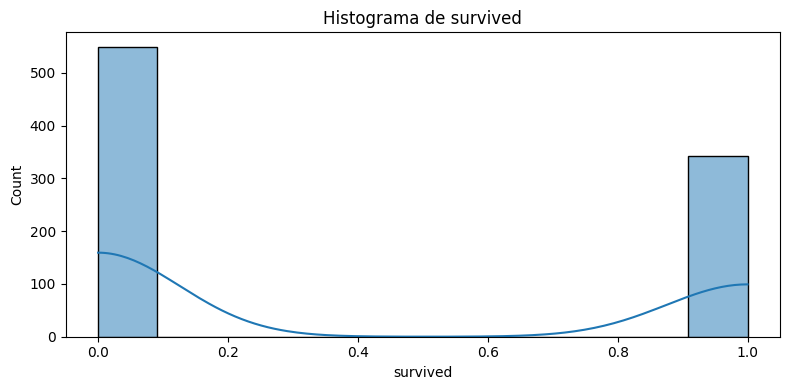

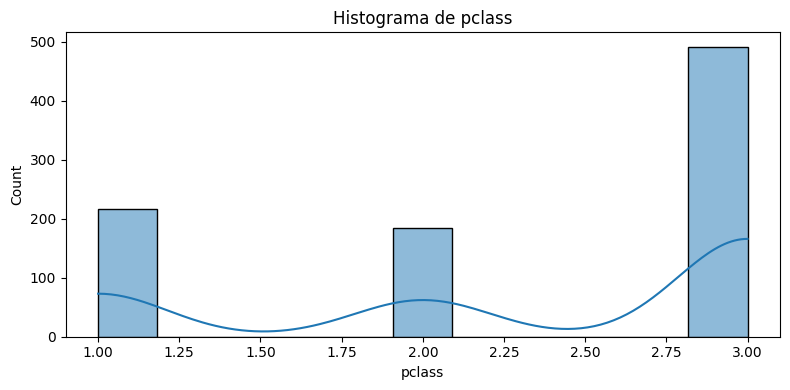

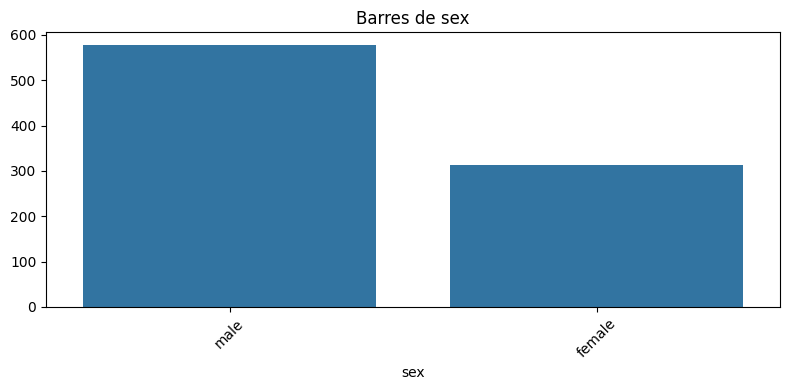

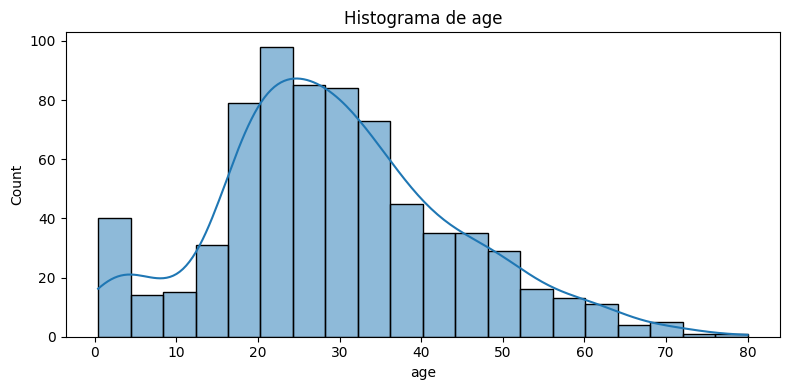

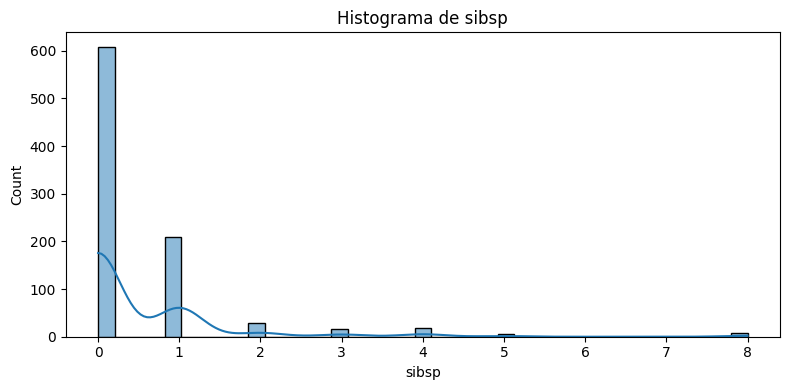

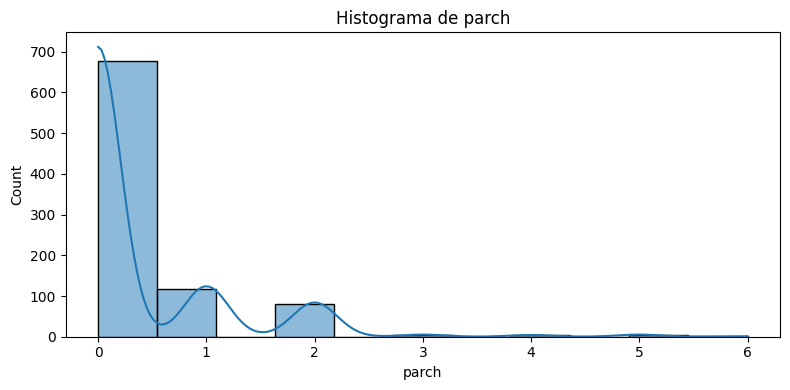

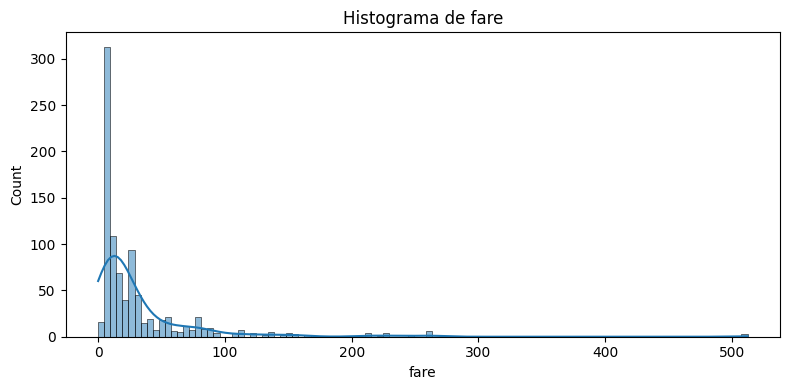

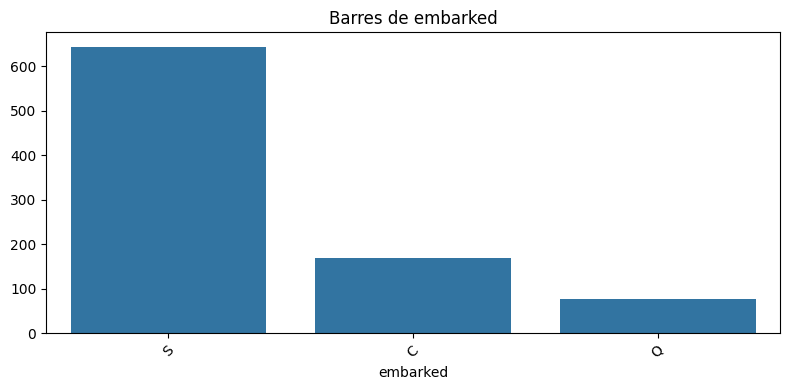

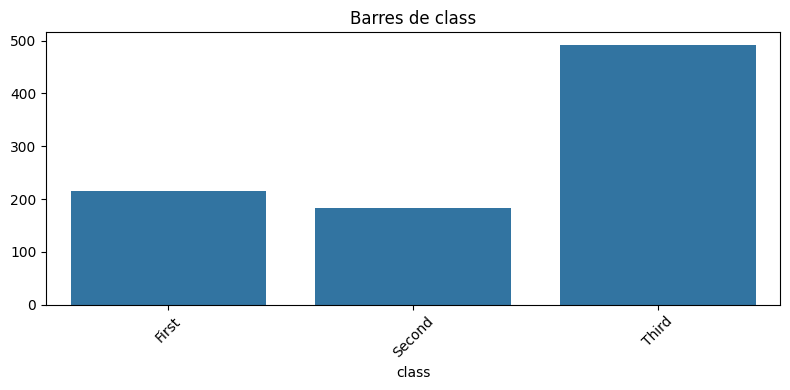

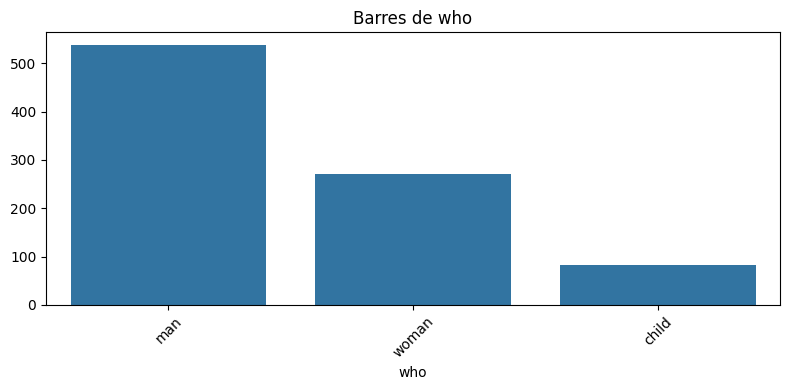

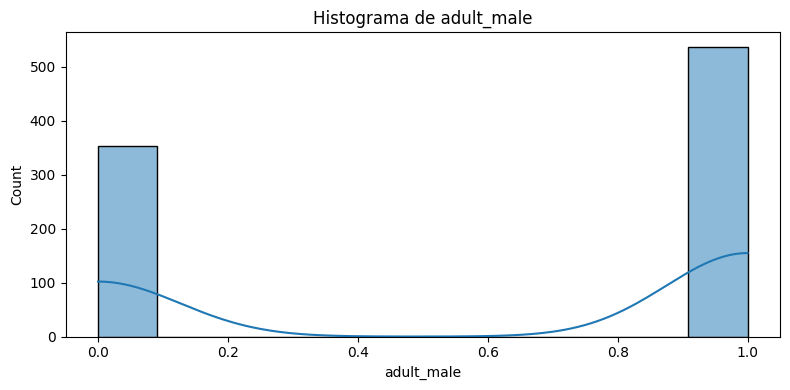

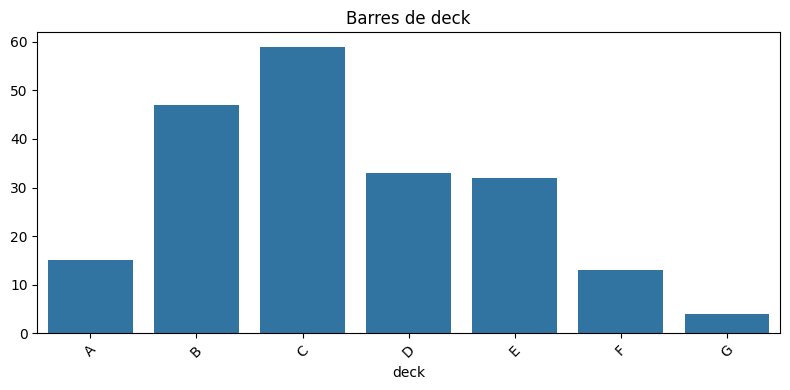

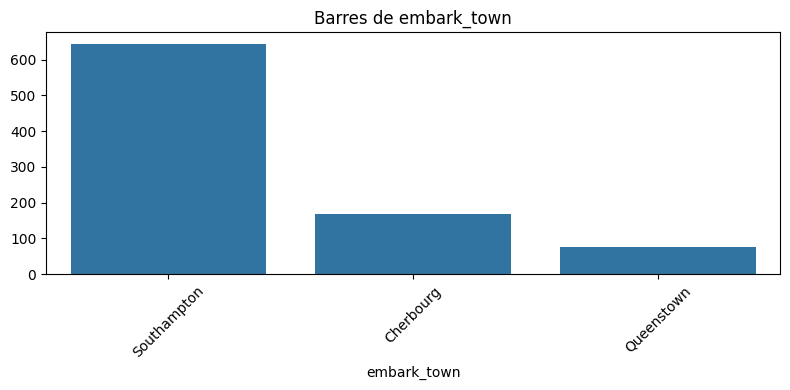

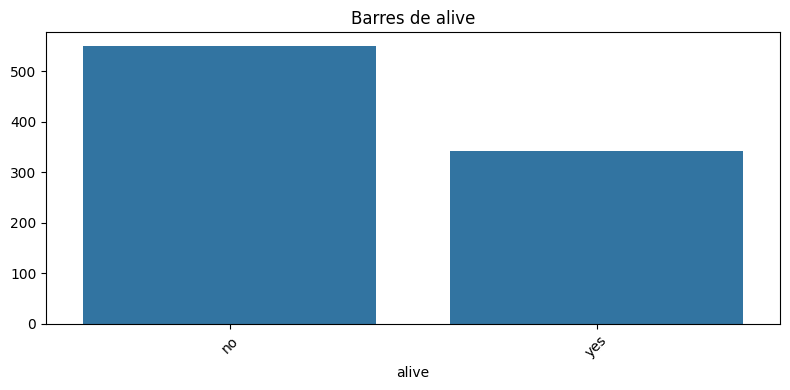

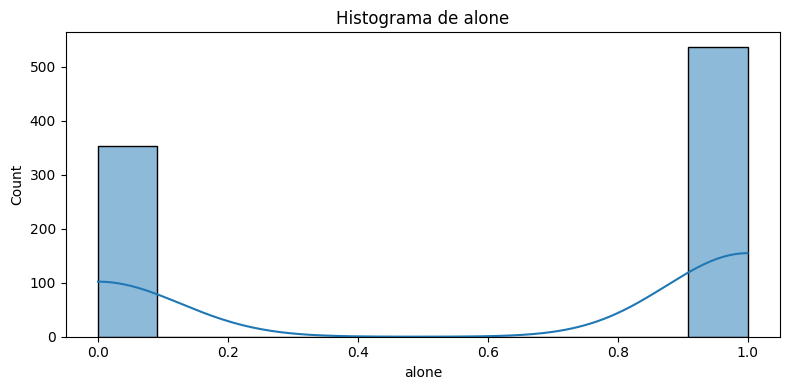

In [737]:
def graficador(df:pd.DataFrame, nombre_del_df=''):
    """
    Genera automáticamente gráficos para cada columna de un DataFrame y los exporta a archivos PNG dentro de una carpeta.

    Inputs:
    -----------
    df : pandas.DataFrame
        El DataFrame que se quiere visualizar.
    nombre_dataset : str
        El nombre del dataset. Se usa para crear la carpeta donde se guardarán los gráficos,
        por ejemplo 'graficos de Titanic'. No se puede inferir automáticamente del DataFrame,
        porque Python no conoce el nombre de la variable que apunta al DataFrame.

    Detalles:
    ---------
    - Columnas numéricas → histograma con curva KDE (curva de distribucion)
    - Columnas categóricas (texto o tipo category) → gráfico de barras de los 10 valores más frecuentes
    - Columnas datetime → gráfico de barras de frecuencia por año
    - Cada gráfico se guarda en la carpeta "graficos de {nombre_dataset}".
    - Se muestran los gráficos en pantalla con plt.show().
    """

    carpeta = f"Grafics de {nombre_del_df}"
    
    if not os.path.exists(carpeta): #sino existe la ruta a carpeta la creamos
        os.makedirs(carpeta)

    for columna in df.columns:
        plt.figure(figsize=(8,4)) #Para cada grafico se crea un figura, sino se superpondrian
        
        if pd.api.types.is_numeric_dtype(df[columna]):
            sns.histplot(df[columna].dropna(), kde=True) #is_numeric_type cubre INT64(nullables) asi que los evitamos con dropna()
            plt.title(f'Histograma de {columna}')
            
        elif isinstance(df[columna].dtype, CategoricalDtype) or df[columna].dtype == object: #usamos isintance para evitar adevertencia
            elementos_contados = df[columna].value_counts().head(10)
            sns.barplot(x=elementos_contados.index, y=elementos_contados.values)
            plt.title(f'Barres de {columna}')
            plt.xticks(rotation=45) #opcional, evita que solape el texto
            
        elif pd.api.types.is_datetime64_any_dtype(df[columna]):
            años = df[columna].dt.year.value_counts().sort_index() #sacamos los años, los contamos y los ordenamos
            sns.barplot(x=años.index, y=años.values)
            plt.title(f'Freq. per any de {columna}')
            plt.xticks(rotation=45)
            
        else:
            print(f"No s'ha reconegut el tipus de la columna {columna}")
            continue
        
        plt.tight_layout()
        plt.savefig(os.path.join(carpeta, f"{columna}.png")) #guardamos en ruta y va antes de plt.show porque este puede borrar la figura
        plt.show()

#Aplicado a Titanic
df_titanic = sns.load_dataset("titanic")
graficador(df_titanic, nombre_del_df='Titanic')

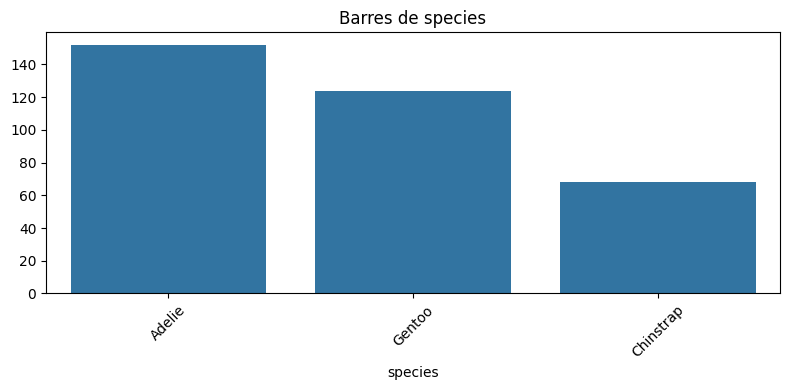

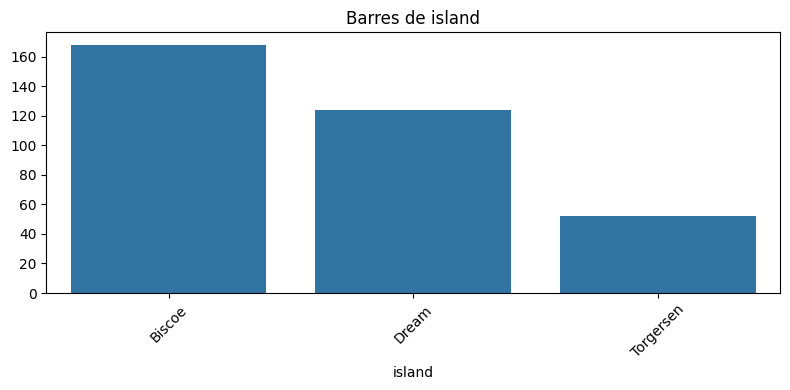

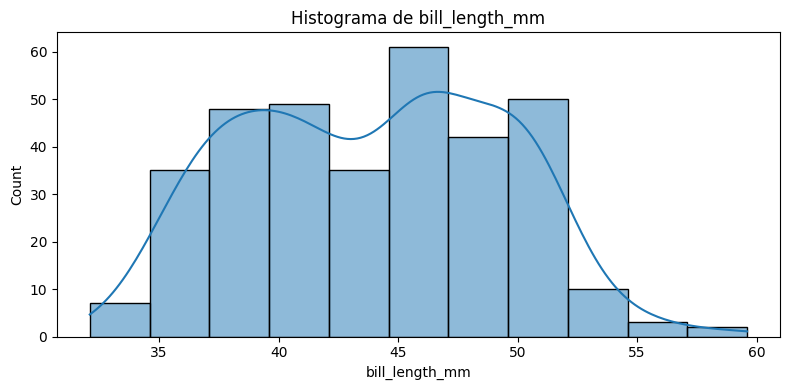

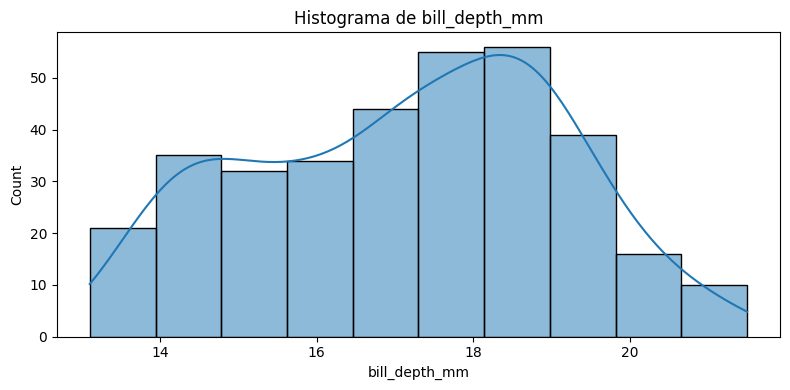

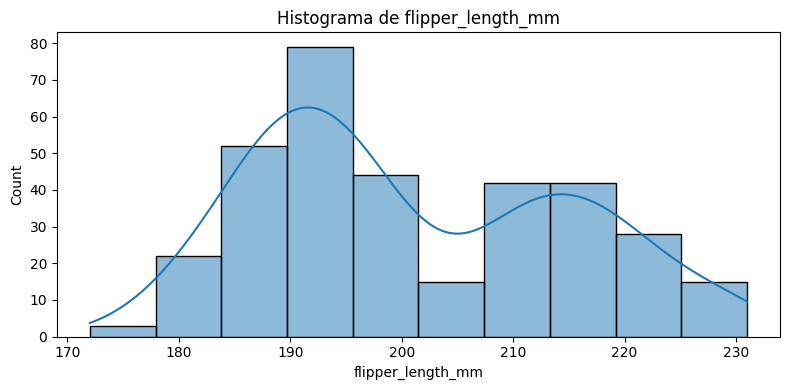

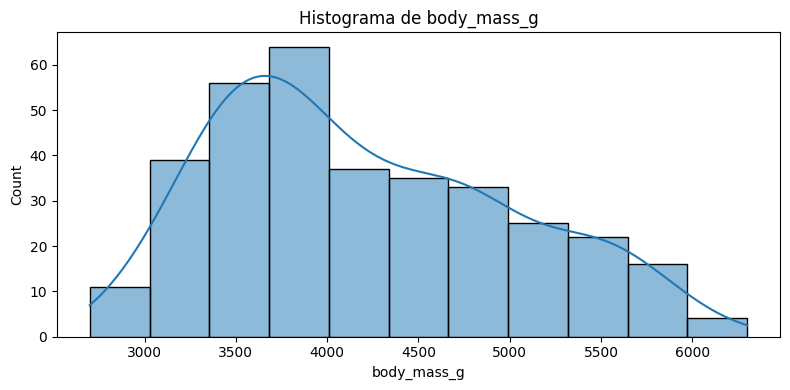

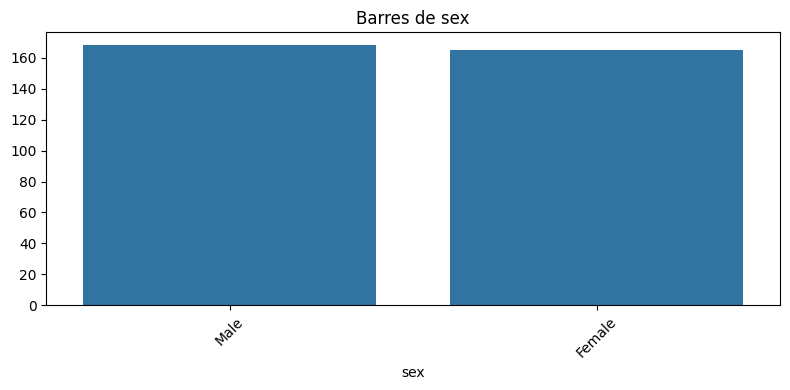

In [738]:
#aplicado a penguins
df_penguins = sns.load_dataset("penguins")
graficador(df_penguins, nombre_del_df='Penguins')

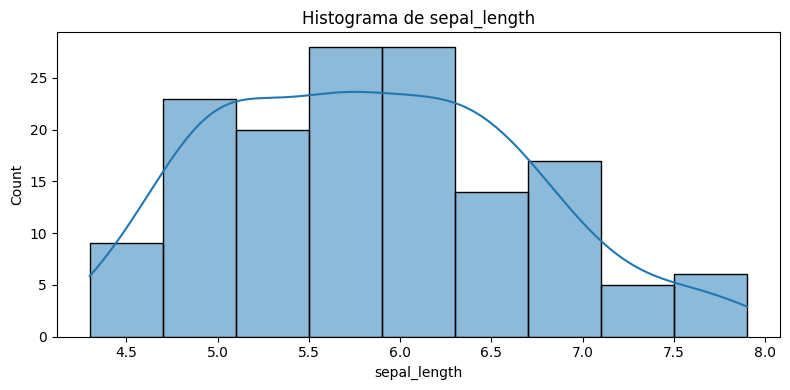

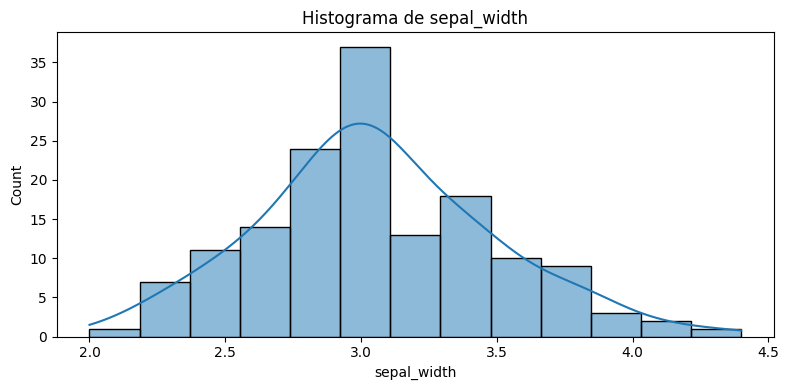

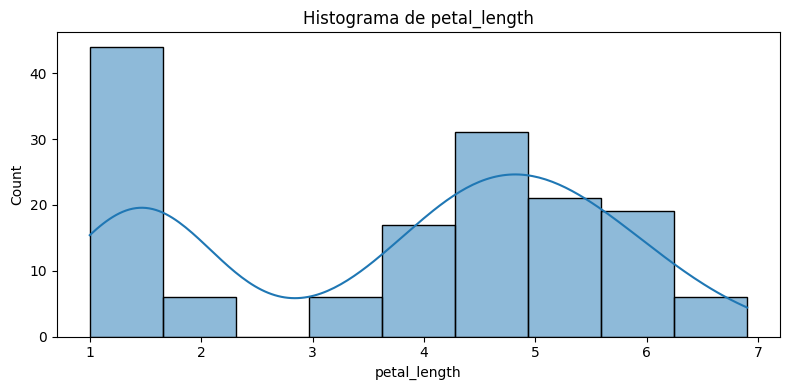

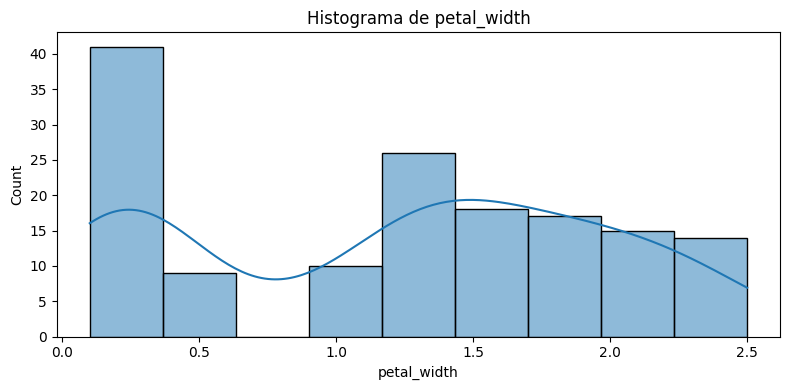

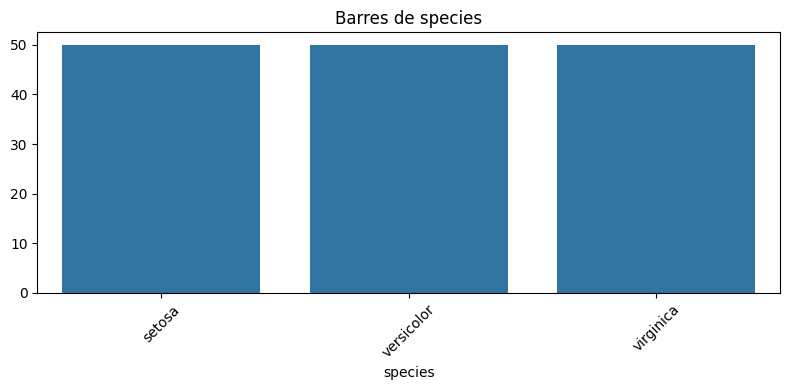

In [739]:
#aplicado a Iris
df_iris = sns.load_dataset("iris")
graficador(df_iris, nombre_del_df='Iris')

2. Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: [Mejores Rutas](https://espana.mejoresrutas.com/tabla-de-distancias/es/)

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat

In [740]:
def cargar_mat_dist(path, ciutats_excloses=None):
    """
    Carga la matriz de distancias desde un archivo Excel + elimina ciudades no deseadas.

    Inputs:
        path (str): Ruta del archivo Excel.
        ciutats_excloses (list, optional): Lista de ciudades a eliminar.

    Output:
        pd.DataFrame: Matriz de distancias limpia.
    """

    try:
        df = pd.read_excel(path, index_col=0)
    except FileNotFoundError:
        raise FileNotFoundError(f"No s'ha trobat l'arxiu: {path}")

    if ciutats_excloses:
        df = df.drop(ciutats_excloses, axis=0, errors='ignore')
        df = df.drop(ciutats_excloses, axis=1, errors='ignore')

    return df

def ruta_cities(dataframe, ciutat_origen):
    """
    Donada la matriu de distàncies (DataFrame) i una ciutat d'origen,
    proposa una ruta aproximada amb la idea del veí més proper.
    
    Retorna:
        - llista amb ordre de visita
        - distància total recorreguda
    """
    ciutats = list(dataframe.columns)
    visitades = [ciutat_origen]
    total_dist = 0
    
    actual = ciutat_origen
    
    while len(visitades) < len(ciutats):
        opcions = dataframe.loc[actual].drop(visitades) #elimina la ciudad que ya hemos vistado de la lista opciones
        seguent = opcions.idxmin() #devuelve el indice, osea ciudad, con el valor minimo
        total_dist += opcions[seguent]
        visitades.append(seguent)
        actual = seguent
    
    total_dist += dataframe.loc[actual, ciutat_origen] #la ruta acaba volviendo al origen
    visitades.append(ciutat_origen)
    
    return visitades, total_dist

def trobar_millor_origen(df):
    """
    Encuentra la mejor ciudad de origen según la distancia total mínima.
    """
    millor_distancia = float('inf') #supuesto de que la mejor distancia inicial es infinita
    millor_origen = None
    millor_ruta = None

    for ciutat in df.columns:
        ruta, dist_total = ruta_cities(df, ciutat)

        if dist_total < millor_distancia: #se actualiza cada vez que encuentre una distancia mejor
            millor_distancia = dist_total
            millor_origen = ciutat
            millor_ruta = ruta

    return millor_origen, millor_ruta, millor_distancia

In [741]:
def main():
    #Carga
    df_distancies = cargar_mat_dist(
        "Data/matriu_distancies.xlsx",
        ["Las Palmas de Gran Canaria", "Palma"]
    )

    #Input del usuario
    ciutat_origen = input("Des de quina ciutat comença la ruta? Opcions: Barcelona, Valencia, Sevilla, Zaragoza, Málaga, Murcia, Bilbao, Alicante, Córdoba	Valladolid, Vigo, Gijón, Hospitalet de Llobregat").capitalize()

    try:
        ruta, total_dist = ruta_cities(df_distancies, ciutat_origen)
    except ValueError:
        print("Error: ciutat no vàlida.")
        return

    #Mejor ciudad origen
    millor_origen, millor_ruta, millor_distancia = trobar_millor_origen(df_distancies)

    #Resultados
    print(f"\nRuta des de {ciutat_origen}:")
    print(ruta)
    print("Distància total:", total_dist)

    print("\nMillor ciutat d'origen:", millor_origen)
    print("Distància mínima:", millor_distancia)
    print("Ruta:", millor_ruta)

In [743]:
if __name__ == "__main__":
    main()


Ruta des de Barcelona:
['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Valladolid', 'Gijón', 'Bilbao', 'Vigo', 'Barcelona']
Distància total: 3686.0

Millor ciutat d'origen: Alicante
Distància mínima: 3541.0
Ruta: ['Alicante', 'Murcia', 'Valencia', 'Zaragoza', 'Bilbao', 'Gijón', 'Valladolid', 'Vigo', 'Sevilla', 'Córdoba', 'Málaga', 'Hospitalet de Llobregat', 'Barcelona', 'Alicante']


Nota personal:

df.loc[etiqueta, columna] --> accede a la fila de la etiqueta que encuentra en el indice y si le damos columna, accede al valor concreto. No es lo mismo que df[columna]

    FEEDBACK:trabajar en la modularidad, usar funcion main() y el manejo de posibles errores.